In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import os
from pathlib import Path

class SimulacionMonteCarloProyecto:
    def __init__(self, ruta_salida="salida_simulacion"):
        self.actividades = {}
        self.dependencias = {}
        self.resultados_simulacion = None
        self.ruta_salida = Path(ruta_salida)
        self.ruta_salida.mkdir(exist_ok=True)
        
        # Crear carpeta con timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.carpeta_ejecucion = self.ruta_salida / f"ejecucion_{timestamp}"
        self.carpeta_ejecucion.mkdir(exist_ok=True)
        
        self.log_trazabilidad = []
        self.agregar_log("INICIO DE SIMULACIÓN MONTE CARLO")

    def agregar_log(self, mensaje, tipo="INFO"):
        """Registrar eventos de trazabilidad"""
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
        entrada = {
            'timestamp': timestamp,
            'tipo': tipo,
            'mensaje': mensaje
        }
        self.log_trazabilidad.append(entrada)
        print(f"[{timestamp}] {tipo}: {mensaje}")

    def cargar_actividades_excel(self, ruta_excel):
        """
        Cargar actividades desde primera hoja del Excel
        Busca automáticamente columnas con nombres similares a:
        - Nombre/Actividad/Tarea
        - Optimista/Minimo
        - MasProbable/Esperado/Promedio
        - Pesimista/Maximo
        """
        try:
            df = pd.read_excel(ruta_excel, sheet_name=0)
            self.agregar_log(f"Excel cargado: {ruta_excel}")
            self.agregar_log(f"Columnas encontradas: {list(df.columns)}", "DEBUG")
            
            # Mapear columnas automáticamente
            col_nombre = self._encontrar_columna(df.columns, ['nombre', 'actividad', 'tarea', 'activity', 'task'])
            col_optimista = self._encontrar_columna(df.columns, ['optimista', 'minimo', 'min', 'pessimistic', 'optimistic'])
            col_probable = self._encontrar_columna(df.columns, ['probable', 'esperado', 'promedio', 'mean', 'most_likely'])
            col_pesimista = self._encontrar_columna(df.columns, ['pesimista', 'maximo', 'max', 'pessimistic'])
            
            if not all([col_nombre, col_optimista, col_probable, col_pesimista]):
                self.agregar_log(f"Error: No se encontraron todas las columnas requeridas", "ERROR")
                return False
            
            self.agregar_log(f"Mapeo de columnas: Nombre={col_nombre}, Optimista={col_optimista}, "
                           f"Probable={col_probable}, Pesimista={col_pesimista}")
            
            for idx, row in df.iterrows():
                nombre = str(row[col_nombre]).strip()
                opt = float(row[col_optimista])
                prob = float(row[col_probable])
                pes = float(row[col_pesimista])
                
                self.agregar_actividad(nombre, opt, prob, pes)
                self.agregar_log(f"Actividad cargada: {nombre} ({opt}, {prob}, {pes})", "DEBUG")
            
            self.agregar_log(f"Total de actividades cargadas: {len(self.actividades)}")
            return True
            
        except Exception as e:
            self.agregar_log(f"Error al cargar Excel: {str(e)}", "ERROR")
            return False

    def cargar_dependencias_excel(self, ruta_excel):
        """
        Cargar dependencias desde segunda hoja del Excel
        Esperado: Columnas 'Actividad' y 'Predecesoras' (separadas por comas)
        """
        try:
            df = pd.read_excel(ruta_excel, sheet_name=1)
            self.agregar_log(f"Segunda hoja cargada para dependencias")
            self.agregar_log(f"Columnas encontradas: {list(df.columns)}", "DEBUG")
            
            # Mapear columnas
            col_actividad = self._encontrar_columna(df.columns, ['actividad', 'activity', 'nombre', 'name', 'tarea'])
            col_predecesoras = self._encontrar_columna(df.columns, ['predecesora', 'predecesoras', 'predecessor', 'dependencia', 'depende_de'])
            
            if not col_actividad:
                self.agregar_log("Error: No se encontró columna de Actividad en dependencias", "ERROR")
                return False
            
            for idx, row in df.iterrows():
                actividad = str(row[col_actividad]).strip()
                
                # Obtener predecesoras
                if pd.isna(row[col_predecesoras]) or str(row[col_predecesoras]).strip() == '':
                    predecesoras = []
                else:
                    predecesoras = [p.strip() for p in str(row[col_predecesoras]).split(',')]
                
                if actividad in self.actividades:
                    self.definir_dependencias(actividad, predecesoras)
                    self.agregar_log(f"Dependencias definidas: {actividad} <- {predecesoras}", "DEBUG")
            
            # Las actividades sin dependencias quedan con lista vacía
            for actividad in self.actividades:
                if actividad not in self.dependencias:
                    self.dependencias[actividad] = []
                    self.agregar_log(f"Actividad sin predecesoras: {actividad}", "DEBUG")
            
            self.agregar_log(f"Dependencias cargadas correctamente")
            return True
            
        except Exception as e:
            self.agregar_log(f"Error al cargar dependencias: {str(e)}", "ERROR")
            return False

    def _encontrar_columna(self, columnas, keywords):
        """Busca una columna que coincida con alguna palabra clave"""
        columnas_lower = {col: col.lower() for col in columnas}
        for col, col_lower in columnas_lower.items():
            for keyword in keywords:
                if keyword.lower() in col_lower:
                    return col
        return None

    def agregar_actividad(self, nombre, optimista, mas_probable, pesimista):
        """Agregar una actividad con tiempos PERT"""
        media_pert = (optimista + 4 * mas_probable + pesimista) / 6
        desviacion_pert = (pesimista - optimista) / 6
        
        self.actividades[nombre] = {
            'optimista': optimista,
            'mas_probable': mas_probable,
            'pesimista': pesimista,
            'media_pert': media_pert,
            'desviacion_pert': desviacion_pert
        }

    def definir_dependencias(self, actividad, predecesoras):
        """Definir dependencias entre actividades"""
        self.dependencias[actividad] = predecesoras

    def generar_tiempo_triangular(self, actividad, n_simulaciones):
        """Generar tiempos aleatorios usando distribución triangular"""
        optimista = self.actividades[actividad]['optimista']
        mas_probable = self.actividades[actividad]['mas_probable']
        pesimista = self.actividades[actividad]['pesimista']
        return np.random.triangular(optimista, mas_probable, pesimista, n_simulaciones)

    def calcular_ruta_critica(self, tiempos_simulados, num_simulacion):
        """Calcular la ruta crítica para cada simulación con trazabilidad"""
        n_simulaciones = len(tiempos_simulados[list(tiempos_simulados.keys())[0]])
        rutas_criticas = []
        duraciones_totales = []
        trazas_critica = []

        for i in range(n_simulaciones):
            traza = {
                'simulacion': i,
                'tiempos_actividades': {},
                'tiempos_tempranos': {},
                'tiempos_tardios': {},
                'holguras': {},
                'ruta_critica': [],
                'duracion_total': 0
            }
            
            # Forward pass
            tiempos_tempranos = {}
            for actividad in sorted(self.actividades.keys()):
                if not self.dependencias.get(actividad, []):
                    tiempos_tempranos[actividad] = tiempos_simulados[actividad][i]
                else:
                    max_predecesor = 0
                    for pred in self.dependencias[actividad]:
                        fin_pred = tiempos_tempranos.get(pred, 0) + tiempos_simulados[pred][i]
                        max_predecesor = max(max_predecesor, fin_pred)
                    tiempos_tempranos[actividad] = max_predecesor
                
                traza['tiempos_tempranos'][actividad] = tiempos_tempranos[actividad]
                traza['tiempos_actividades'][actividad] = tiempos_simulados[actividad][i]

            duracion_total = max(tiempos_tempranos.values())
            duraciones_totales.append(duracion_total)
            traza['duracion_total'] = duracion_total

            # Backward pass
            tiempos_tardios = {}
            for actividad in sorted(self.actividades.keys(), reverse=True):
                sucesores = [act for act, preds in self.dependencias.items() if actividad in preds]
                
                if not sucesores:
                    tiempos_tardios[actividad] = duracion_total - tiempos_simulados[actividad][i]
                else:
                    min_inicio_sucesor = float('inf')
                    for suc in sucesores:
                        min_inicio_sucesor = min(min_inicio_sucesor, tiempos_tardios.get(suc, duracion_total))
                    tiempos_tardios[actividad] = min_inicio_sucesor - tiempos_simulados[actividad][i]
                
                traza['tiempos_tardios'][actividad] = tiempos_tardios[actividad]

            # Calcular holguras y ruta crítica
            ruta_critica = []
            for actividad in self.actividades:
                holgura = tiempos_tardios.get(actividad, 0) - tiempos_tempranos.get(actividad, 0)
                traza['holguras'][actividad] = holgura
                
                if abs(holgura) < 1e-6:
                    ruta_critica.append(actividad)

            traza['ruta_critica'] = sorted(ruta_critica)
            rutas_criticas.append(ruta_critica)
            trazas_critica.append(traza)

        return rutas_criticas, duraciones_totales, trazas_critica

    def simular(self, n_corridas=1000):
        """Ejecutar simulación Monte Carlo con trazabilidad completa"""
        self.agregar_log(f"Iniciando simulación con {n_corridas} corridas")
        
        # Generar tiempos simulados
        tiempos_simulados = {}
        for actividad in sorted(self.actividades.keys()):
            tiempos_simulados[actividad] = self.generar_tiempo_triangular(actividad, n_corridas)
            self.agregar_log(f"Tiempos generados para {actividad}", "DEBUG")

        # Guardar tiempos generados
        df_tiempos = pd.DataFrame(tiempos_simulados)
        archivo_tiempos = self.carpeta_ejecucion / "01_tiempos_generados.csv"
        df_tiempos.to_csv(archivo_tiempos, index_label='simulacion')
        self.agregar_log(f"Tiempos guardados en: {archivo_tiempos}")

        # Calcular rutas críticas
        self.agregar_log("Calculando rutas críticas para cada simulación...")
        rutas_criticas, duraciones_totales, trazas_critica = self.calcular_ruta_critica(tiempos_simulados, 0)
        self.agregar_log(f"Rutas críticas calculadas para {len(rutas_criticas)} simulaciones")

        # Guardar trazabilidad completa
        self._guardar_trazabilidad_completa(trazas_critica)

        self.resultados_simulacion = {
            'tiempos_simulados': tiempos_simulados,
            'rutas_criticas': rutas_criticas,
            'duraciones_totales': duraciones_totales,
            'trazas_critica': trazas_critica,
            'n_corridas': n_corridas
        }

        return self.resultados_simulacion

    def _guardar_trazabilidad_completa(self, trazas_critica):
        """Guardar todas las trazas de las rutas críticas"""
        # Archivo de trazabilidad simplificada
        datos_trazas = []
        for traza in trazas_critica:
            datos_trazas.append({
                'simulacion': traza['simulacion'],
                'duracion_total': traza['duracion_total'],
                'ruta_critica': '->'.join(traza['ruta_critica']),
                'num_actividades_criticas': len(traza['ruta_critica'])
            })
        
        df_trazas = pd.DataFrame(datos_trazas)
        archivo_trazas = self.carpeta_ejecucion / "02_trazabilidad_rutas_criticas.csv"
        df_trazas.to_csv(archivo_trazas, index=False)
        self.agregar_log(f"Trazabilidad de rutas guardada en: {archivo_trazas}")

        # Archivo detallado: tiempos tempranos y tardíos
        todos_tempranos = []
        todos_tardios = []
        todas_holguras = []
        
        for traza in trazas_critica:
            for actividad in self.actividades:
                todos_tempranos.append({
                    'simulacion': traza['simulacion'],
                    'actividad': actividad,
                    'tiempo_temprano': traza['tiempos_tempranos'].get(actividad, 0),
                    'tiempo_actual': traza['tiempos_actividades'].get(actividad, 0)
                })
                todos_tardios.append({
                    'simulacion': traza['simulacion'],
                    'actividad': actividad,
                    'tiempo_tardio': traza['tiempos_tardios'].get(actividad, 0),
                    'duracion_total': traza['duracion_total']
                })
                todas_holguras.append({
                    'simulacion': traza['simulacion'],
                    'actividad': actividad,
                    'holgura': traza['holguras'].get(actividad, 0),
                    'es_critica': abs(traza['holguras'].get(actividad, 0)) < 1e-6
                })

        df_tempranos = pd.DataFrame(todos_tempranos)
        df_tardios = pd.DataFrame(todos_tardios)
        df_holguras = pd.DataFrame(todas_holguras)

        df_tempranos.to_csv(self.carpeta_ejecucion / "03_tiempos_tempranos.csv", index=False)
        df_tardios.to_csv(self.carpeta_ejecucion / "04_tiempos_tardios.csv", index=False)
        df_holguras.to_csv(self.carpeta_ejecucion / "05_holguras_y_criticidad.csv", index=False)
        
        self.agregar_log("Archivos detallados de tiempos y holguras guardados")

    def analizar_resultados(self):
        """Analizar y mostrar resultados"""
        if self.resultados_simulacion is None:
            self.agregar_log("Primero ejecute la simulación", "ERROR")
            return

        duraciones = self.resultados_simulacion['duraciones_totales']

        print("\n" + "="*50)
        print("ANÁLISIS DE RESULTADOS MONTE CARLO")
        print("="*50)
        print(f"Número de simulaciones: {self.resultados_simulacion['n_corridas']}")
        print(f"Duración promedio: {np.mean(duraciones):.2f} días")
        print(f"Duración mínima: {np.min(duraciones):.2f} días")
        print(f"Duración máxima: {np.max(duraciones):.2f} días")
        print(f"Desviación estándar: {np.std(duraciones):.2f} días")

        # Percentiles
        print("\nPERCENTILES:")
        for percentil in [50, 75, 90, 95, 99]:
            valor = np.percentile(duraciones, percentil)
            print(f"  P{percentil}: {valor:.2f} días")

        # Rutas críticas
        rutas_criticas = self.resultados_simulacion['rutas_criticas']
        frecuencia_rutas = {}
        for ruta in rutas_criticas:
            clave = tuple(sorted(ruta))
            frecuencia_rutas[clave] = frecuencia_rutas.get(clave, 0) + 1

        print("\nRUTAS CRÍTICAS MÁS FRECUENTES:")
        for ruta, frecuencia in sorted(frecuencia_rutas.items(), key=lambda x: x[1], reverse=True)[:10]:
            prob = (frecuencia / len(rutas_criticas)) * 100
            print(f"  {' -> '.join(ruta)}: {prob:.1f}%")

        # Frecuencia de actividades críticas
        print("\nFRECUENCIA DE ACTIVIDADES EN RUTA CRÍTICA:")
        frecuencia_actividades = {}
        for ruta in rutas_criticas:
            for actividad in ruta:
                frecuencia_actividades[actividad] = frecuencia_actividades.get(actividad, 0) + 1

        for actividad, frecuencia in sorted(frecuencia_actividades.items(), key=lambda x: x[1], reverse=True):
            prob = (frecuencia / len(rutas_criticas)) * 100
            print(f"  {actividad}: {prob:.1f}%")

        # Guardar análisis en archivo
        self._guardar_analisis(duraciones, frecuencia_rutas, frecuencia_actividades)
        self.agregar_log("Análisis completado y guardado")

    def _guardar_analisis(self, duraciones, frecuencia_rutas, frecuencia_actividades):
        """Guardar análisis en archivos"""
        # Resumen estadístico
        resumen = {
            'Metrica': [
                'Número de simulaciones',
                'Duración Promedio (días)',
                'Duración Mínima (días)',
                'Duración Máxima (días)',
                'Desviación Estándar (días)',
                'P50 (días)',
                'P75 (días)',
                'P90 (días)',
                'P95 (días)',
                'P99 (días)'
            ],
            'Valor': [
                len(duraciones),
                f'{np.mean(duraciones):.2f}',
                f'{np.min(duraciones):.2f}',
                f'{np.max(duraciones):.2f}',
                f'{np.std(duraciones):.2f}',
                f'{np.percentile(duraciones, 50):.2f}',
                f'{np.percentile(duraciones, 75):.2f}',
                f'{np.percentile(duraciones, 90):.2f}',
                f'{np.percentile(duraciones, 95):.2f}',
                f'{np.percentile(duraciones, 99):.2f}'
            ]
        }
        df_resumen = pd.DataFrame(resumen)
        df_resumen.to_csv(self.carpeta_ejecucion / "06_resumen_estadistico.csv", index=False)

        # Rutas críticas frecuentes
        datos_rutas = []
        for idx, (ruta, frecuencia) in enumerate(sorted(frecuencia_rutas.items(), key=lambda x: x[1], reverse=True)):
            prob = (frecuencia / sum(frecuencia_rutas.values())) * 100
            datos_rutas.append({
                'Rango': idx + 1,
                'Ruta': '->'.join(ruta),
                'Frecuencia': frecuencia,
                'Probabilidad (%)': f'{prob:.2f}'
            })
        df_rutas = pd.DataFrame(datos_rutas)
        df_rutas.to_csv(self.carpeta_ejecucion / "07_rutas_criticas_frecuentes.csv", index=False)

        # Actividades críticas
        datos_actividades = []
        for actividad, frecuencia in sorted(frecuencia_actividades.items(), key=lambda x: x[1], reverse=True):
            prob = (frecuencia / len(self.resultados_simulacion['rutas_criticas'])) * 100
            datos_actividades.append({
                'Actividad': actividad,
                'Frecuencia en Ruta Crítica': frecuencia,
                'Probabilidad (%)': f'{prob:.2f}',
                'Optimista': self.actividades[actividad]['optimista'],
                'Más Probable': self.actividades[actividad]['mas_probable'],
                'Pesimista': self.actividades[actividad]['pesimista'],
                'Media PERT': f'{self.actividades[actividad]["media_pert"]:.2f}',
                'Desviación': f'{self.actividades[actividad]["desviacion_pert"]:.2f}'
            })
        df_actividades = pd.DataFrame(datos_actividades)
        df_actividades.to_csv(self.carpeta_ejecucion / "08_analisis_actividades.csv", index=False)

    def graficar_resultados(self):
        """Graficar los resultados"""
        if self.resultados_simulacion is None:
            self.agregar_log("Primero ejecute la simulación", "ERROR")
            return

        duraciones = self.resultados_simulacion['duraciones_totales']

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

        # Histograma
        ax1.hist(duraciones, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.axvline(np.mean(duraciones), color='red', linestyle='--', 
                   label=f'Media: {np.mean(duraciones):.2f}')
        ax1.set_xlabel('Duración del Proyecto (días)')
        ax1.set_ylabel('Frecuencia')
        ax1.set_title('Distribución de Duraciones')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # FDA
        sorted_data = np.sort(duraciones)
        y_vals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
        ax2.plot(sorted_data, y_vals, linewidth=2)
        ax2.set_xlabel('Duración del Proyecto (días)')
        ax2.set_ylabel('Probabilidad Acumulada')
        ax2.set_title('Función de Distribución Acumulada')
        ax2.grid(True, alpha=0.3)

        # Boxplot actividades
        actividades_muestra = sorted(list(self.actividades.keys()))[:min(20, len(self.actividades))]
        datos = [self.resultados_simulacion['tiempos_simulados'][act] for act in actividades_muestra]
        ax3.boxplot(datos, labels=actividades_muestra)
        ax3.set_ylabel('Duración (días)')
        ax3.set_title('Variabilidad por Actividad')
        ax3.tick_params(axis='x', rotation=45)

        # Sensibilidad
        correlaciones = {}
        for actividad in self.actividades:
            correlacion = np.corrcoef(self.resultados_simulacion['tiempos_simulados'][actividad], 
                                     duraciones)[0, 1]
            correlaciones[actividad] = abs(correlacion)

        items_ord = sorted(correlaciones.items(), key=lambda x: x[1], reverse=True)[:8]
        nombres = [item[0] for item in items_ord]
        valores = [item[1] for item in items_ord]
        ax4.barh(nombres, valores, color='lightcoral')
        ax4.set_xlabel('Correlación con Duración Total')
        ax4.set_title('Análisis de Sensibilidad')

        plt.tight_layout()
        archivo_grafico = self.carpeta_ejecucion / "09_graficos_analisis.png"
        plt.savefig(archivo_grafico, dpi=300, bbox_inches='tight')
        plt.show()
        self.agregar_log(f"Gráficos guardados en: {archivo_grafico}")

    def guardar_log(self):
        """Guardar log de trazabilidad"""
        df_log = pd.DataFrame(self.log_trazabilidad)
        archivo_log = self.carpeta_ejecucion / "00_log_ejecucion.csv"
        df_log.to_csv(archivo_log, index=False)
        self.agregar_log(f"Log guardado en: {archivo_log}")

    def generar_resumen_ejecucion(self):
        """Generar resumen final de la ejecución"""
        resumen_txt = f"""
RESUMEN DE EJECUCIÓN MONTE CARLO
================================
Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Carpeta: {self.carpeta_ejecucion}

CONFIGURACIÓN:
- Número de actividades: {len(self.actividades)}
- Número de simulaciones: {self.resultados_simulacion['n_corridas']}

ACTIVIDADES CARGADAS:
"""
        for nombre, datos in sorted(self.actividades.items()):
            resumen_txt += f"\n  {nombre}: ({datos['optimista']}, {datos['mas_probable']}, {datos['pesimista']})"
        
        resumen_txt += f"\n\nDEPENDENCIAS:\n"
        for act, preds in sorted(self.dependencias.items()):
            preds_str = '->'.join(preds) if preds else 'INICIO'
            resumen_txt += f"\n  {act} depende de: {preds_str}"

        resumen_txt += f"\n\nARCHIVOS GENERADOS:\n"
        for archivo in sorted(self.carpeta_ejecucion.glob('*.csv')):
            resumen_txt += f"\n  - {archivo.name}"
        
        archivo_resumen = self.carpeta_ejecucion / "RESUMEN_EJECUCION.txt"
        with open(archivo_resumen, 'w') as f:
            f.write(resumen_txt)
        
        print(resumen_txt)
        self.agregar_log(f"Resumen de ejecución guardado en: {archivo_resumen}")





In [19]:
# EJEMPLO DE USO
def ejemplo_simulacion_desde_excel():
    """
    Ejemplo de uso cargando datos desde Excel
    El Excel debe tener:
    - Hoja 1: Actividades (Nombre, Optimista, Mas Probable, Pesimista)
    - Hoja 2: Dependencias (Actividad, Predecesoras)
    """
    
    # Crear simulador
    simulador = SimulacionMonteCarloProyecto(ruta_salida="salida_simulacion")
    
    # Cargar datos desde Excel
    ruta_excel = "datos_proyecto.xlsx"  # CAMBIAR POR TU ARCHIVO
    
    if not os.path.exists(ruta_excel):
        print(f"ERROR: El archivo {ruta_excel} no existe")
        print("Creando archivo de ejemplo...")
        crear_excel_ejemplo(ruta_excel)
    
    # Cargar actividades
    if simulador.cargar_actividades_excel(ruta_excel):
        # Cargar dependencias
        if simulador.cargar_dependencias_excel(ruta_excel):
            # Ejecutar simulación
            print("\n" + "="*50)
            print("Ejecutando simulación con 1000 corridas...")
            print("="*50 + "\n")
            simulador.simular(n_corridas=1000)
            
            # Análisis
            simulador.analizar_resultados()
            
            # Gráficos
            simulador.graficar_resultados()
            
            # Guardar logs
            simulador.guardar_log()
            
            # Resumen
            simulador.generar_resumen_ejecucion()
            
            print(f"\n✓ Simulación completada exitosamente")
            print(f"✓ Todos los archivos guardados en: {simulador.carpeta_ejecucion}")
            
            return simulador
    
    return None
def crear_excel_ejemplo(nombre_archivo):
    """Crear un Excel de ejemplo"""
    # Hoja 1: Actividades
    df_actividades = pd.DataFrame({
        'Nombre': ['A', 'B', 'C', 'D', 'E', 'F'],
        'Optimista': [5, 8, 6, 9, 4, 7],
        'Mas_Probable': [7, 10, 8, 12, 6, 9],
        'Pesimista': [12, 15, 11, 18, 8, 14]
    })
    
    # Hoja 2: Dependencias
    df_dependencias = pd.DataFrame({
        'Actividad': ['A', 'B', 'C', 'D', 'E', 'F'],
        'Predecesoras': ['', 'A', 'A', 'B', 'C', 'D,E']
    })
    
    # Crear archivo Excel con dos hojas
    with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:
        df_actividades.to_excel(writer, sheet_name='Actividades', index=False)
        df_dependencias.to_excel(writer, sheet_name='Dependencias', index=False)
    
    print(f"✓ Archivo de ejemplo creado: {nombre_archivo}")


[2025-10-19 17:17:11.184] INFO: INICIO DE SIMULACIÓN MONTE CARLO
[2025-10-19 17:17:11.199] INFO: Excel cargado: datos_proyecto.xlsx
[2025-10-19 17:17:11.199] DEBUG: Columnas encontradas: ['Nombre', 'Optimista', 'Mas_Probable', 'Pesimista']
[2025-10-19 17:17:11.199] INFO: Mapeo de columnas: Nombre=Nombre, Optimista=Optimista, Probable=Mas_Probable, Pesimista=Pesimista
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: A (5.0, 7.0, 12.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: B (8.0, 10.0, 15.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: C (6.0, 8.0, 11.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: D (9.0, 12.0, 18.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: E (4.0, 6.0, 8.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: F (7.0, 9.0, 14.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: G (10.0, 13.0, 18.0)
[2025-10-19 17:17:11.199] DEBUG: Actividad cargada: H (6.0, 9.0, 18.0)
[2025-10-19 17:17:11.199] INFO: Total de actividades cargad

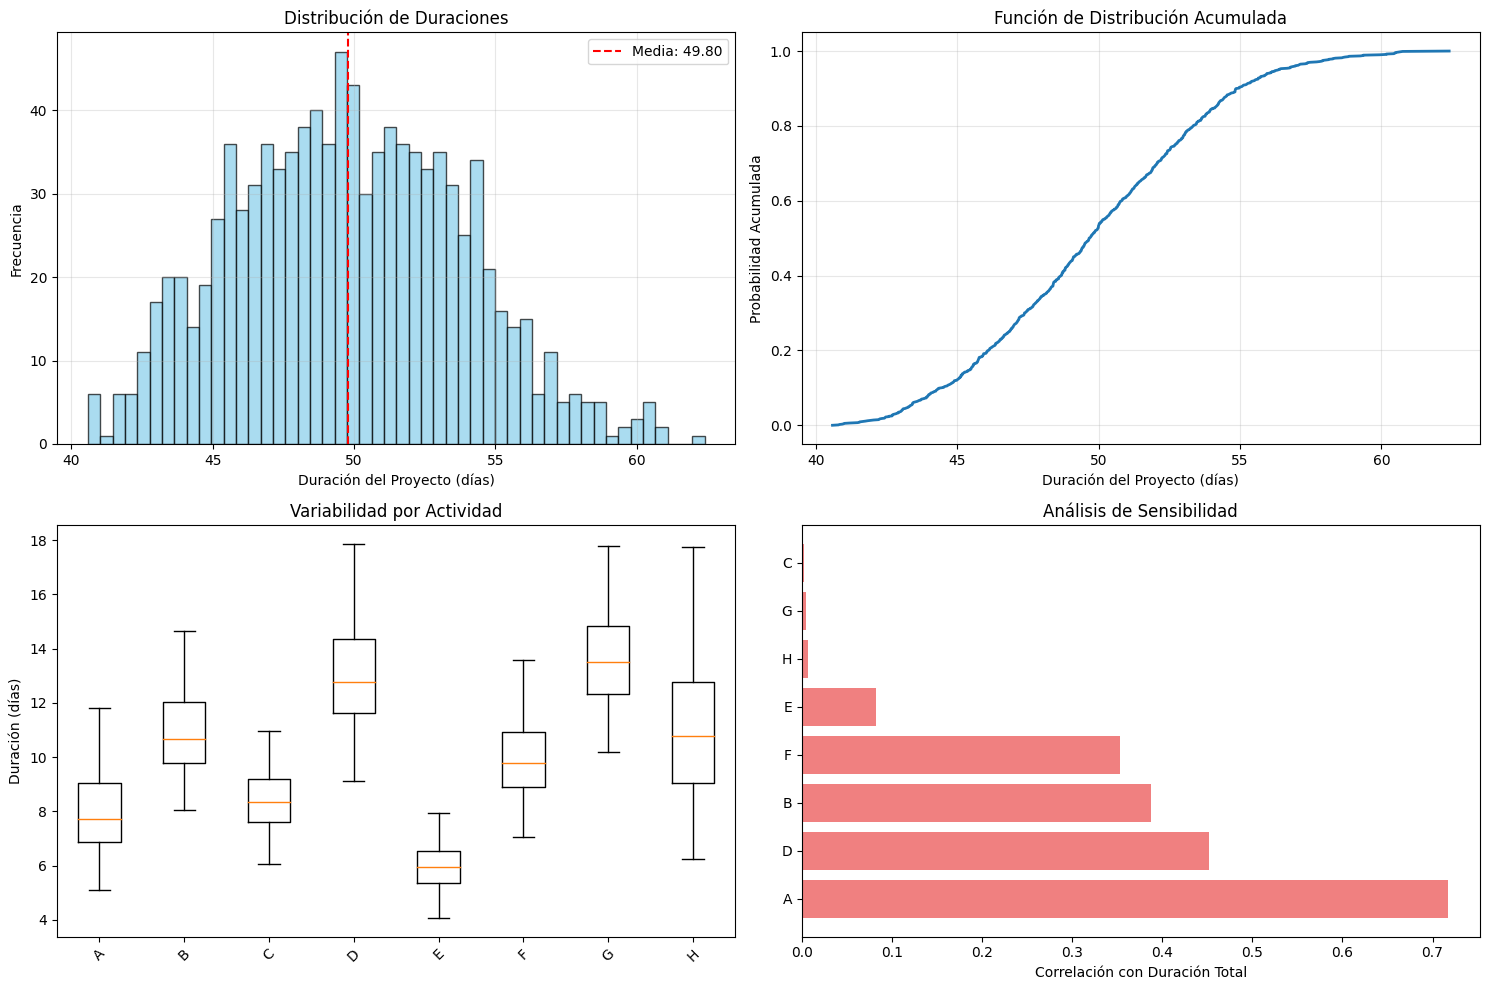

[2025-10-19 17:17:13.855] INFO: Gráficos guardados en: salida_simulacion\ejecucion_20251019_171711\09_graficos_analisis.png
[2025-10-19 17:17:13.858] INFO: Log guardado en: salida_simulacion\ejecucion_20251019_171711\00_log_ejecucion.csv

RESUMEN DE EJECUCIÓN MONTE CARLO
Fecha: 2025-10-19 17:17:13
Carpeta: salida_simulacion\ejecucion_20251019_171711

CONFIGURACIÓN:
- Número de actividades: 8
- Número de simulaciones: 1000

ACTIVIDADES CARGADAS:

  A: (5.0, 7.0, 12.0)
  B: (8.0, 10.0, 15.0)
  C: (6.0, 8.0, 11.0)
  D: (9.0, 12.0, 18.0)
  E: (4.0, 6.0, 8.0)
  F: (7.0, 9.0, 14.0)
  G: (10.0, 13.0, 18.0)
  H: (6.0, 9.0, 18.0)

DEPENDENCIAS:

  A depende de: INICIO
  B depende de: A
  C depende de: A
  D depende de: B
  E depende de: C
  F depende de: D->E
  G depende de: E
  H depende de: F

ARCHIVOS GENERADOS:

  - 00_log_ejecucion.csv
  - 01_tiempos_generados.csv
  - 02_trazabilidad_rutas_criticas.csv
  - 03_tiempos_tempranos.csv
  - 04_tiempos_tardios.csv
  - 05_holguras_y_criticidad.csv

In [20]:
ejemplo_simulacion_desde_excel()